Episode 1/200 | Return(sum): -13772.7 | Avg reward/step: -19.129 | End BF gap: 2.10 | Steps: 720 | eps=0.986
Episode 2/200 | Return(sum): -12827.4 | Avg reward/step: -17.816 | End BF gap: 2.61 | Steps: 720 | eps=0.973
Episode 3/200 | Return(sum): -12660.2 | Avg reward/step: -17.584 | End BF gap: 2.67 | Steps: 720 | eps=0.959
Episode 4/200 | Return(sum): -11255.0 | Avg reward/step: -15.632 | End BF gap: 2.71 | Steps: 720 | eps=0.945
Episode 5/200 | Return(sum): -11369.8 | Avg reward/step: -15.791 | End BF gap: 2.66 | Steps: 720 | eps=0.932
Episode 6/200 | Return(sum): -12047.0 | Avg reward/step: -16.732 | End BF gap: 3.32 | Steps: 720 | eps=0.918
Episode 7/200 | Return(sum): -12239.9 | Avg reward/step: -17.000 | End BF gap: 2.83 | Steps: 720 | eps=0.904
Episode 8/200 | Return(sum): -11694.0 | Avg reward/step: -16.242 | End BF gap: 3.00 | Steps: 720 | eps=0.891
Episode 9/200 | Return(sum): -9878.4 | Avg reward/step: -13.720 | End BF gap: 2.83 | Steps: 720 | eps=0.877
Episode 10/200 | Ret

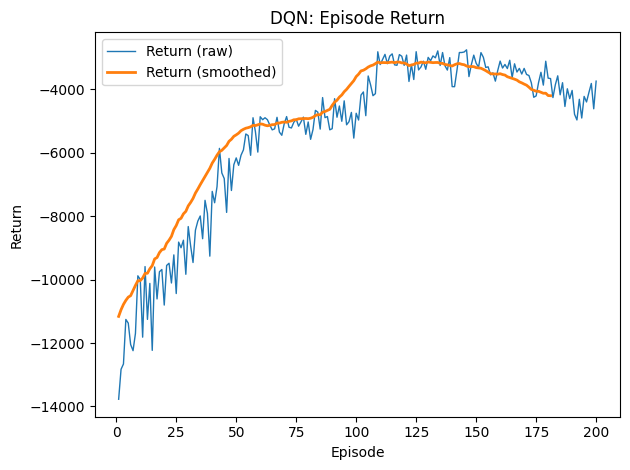

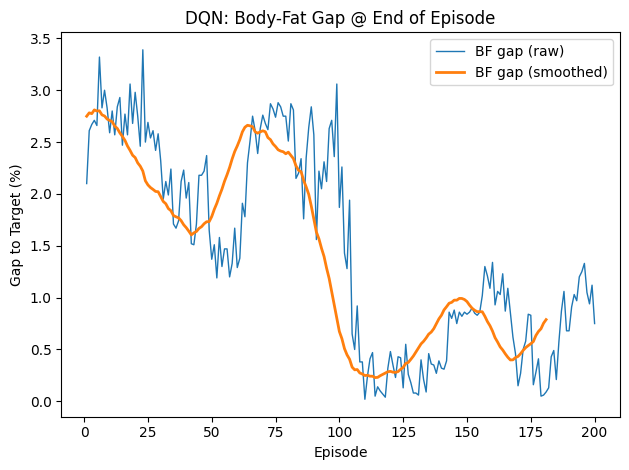

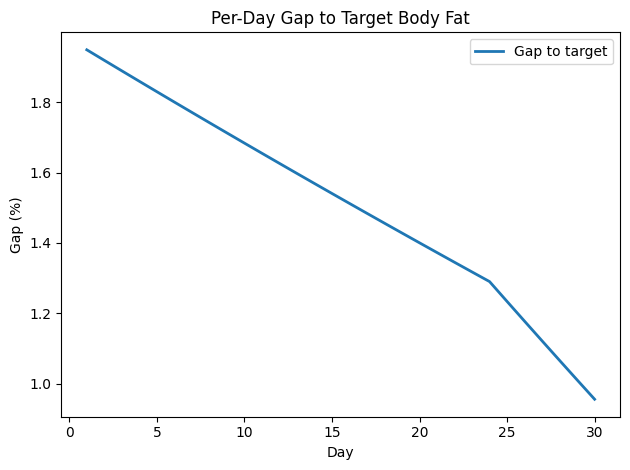

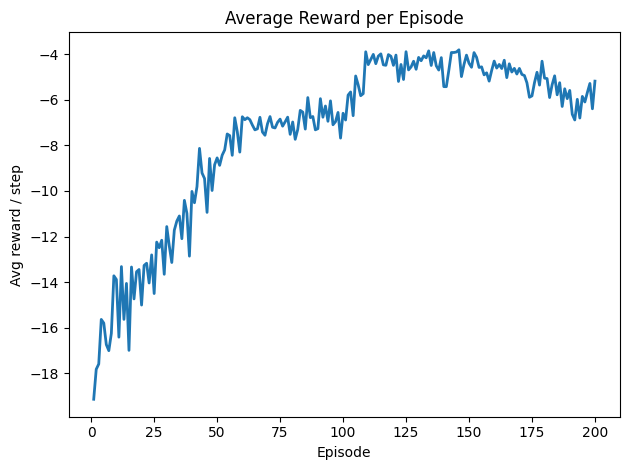

In [3]:
# ---------- SchedulerEnv (only the parts that change) ----------
import numpy as np
import gymnasium as gym
from typing import Optional
import copy

class SchedulerEnv(gym.Env):
    def __init__(
        self,
        gender: int = 1,
        age: int = 25,
        height: float = 175.0,
        weight: float = 70.0,
        target_body_fat: float = 15.0,
        days_per_episode: int = 30,
        workloads: float = 1.5,
        sleep_duration: int = 8,
        verbose: bool = False,
        # NEW: generalization knobs (default OFF → nothing changes unless you opt in)
        domain_randomize: bool = False,
        include_context: bool = False,
        seed: Optional[int] = None,
    ):
        super().__init__()
        self.rng = np.random.default_rng(seed)

        # base (can be overwritten if we randomize at reset)
        self.gender = gender
        self.age = age
        self.height = height
        self.weight = weight
        self.target_body_fat = target_body_fat
        self.days_per_episode = days_per_episode
        self.workloads = workloads
        self.sleep_duration = sleep_duration
        self.verbose = verbose

        # NEW toggles
        self.domain_randomize = domain_randomize
        self.include_context = include_context

        self.daily_meal_target = {
            "fiber": 34,          # grams
            "fat": 0.26,          # fraction of daily calories
            "carbs": 0.56,        # fraction
            "protein": 0.18       # fraction
        }

        self.daily_total_targets = {
            "water": 3.7,         # liters
            "calcium": 1000,      # mg
            "iron": 8,            # mg
            "vitamin_c": 90       # mg
        }

        self.hours_per_day = 24
        self._build_scheduler()

        # ----- state & spaces -----
        self.state = self._init_state_from_params()

        # observation space (original keys)
        obs_space_dict = {
            "current_weight":      gym.spaces.Box(low=30.0,  high=300.0,  shape=(1,), dtype=np.float32),
            "current_bmi":         gym.spaces.Box(low=15.0,  high=50.0,   shape=(1,), dtype=np.float32),
            "current_body_fat":    gym.spaces.Box(low=5.0,   high=50.0,   shape=(1,), dtype=np.float32),
            "current_hours":       gym.spaces.Discrete(self.hours_per_day),
            "day_of_episode":      gym.spaces.Box(low=0,     high=self.days_per_episode, shape=(1,), dtype=np.int32),
            "time_since_last_meal":     gym.spaces.Box(low=0, high=24, shape=(1,), dtype=np.int32),
            "time_since_last_exercise": gym.spaces.Box(low=0, high=self.days_per_episode*24, shape=(1,), dtype=np.int32),
            "daily_calories_burned": gym.spaces.Box(low=0.0, high=4000.0, shape=(1,), dtype=np.float32),
            "daily_calories_intake": gym.spaces.Box(low=0.0, high=4000.0, shape=(1,), dtype=np.float32),
            "daily_calories":      gym.spaces.Box(low=500.0, high=3000.0, shape=(1,), dtype=np.float32),
            "daily_fiber_intake":  gym.spaces.Box(low=0.0,  high=50.0,   shape=(1,), dtype=np.float32),
            "daily_fat_intake":    gym.spaces.Box(low=0.0,  high=200.0,  shape=(1,), dtype=np.float32),
            "daily_carbs_intake":  gym.spaces.Box(low=0.0,  high=600.0,  shape=(1,), dtype=np.float32),
            "daily_protein_intake":gym.spaces.Box(low=0.0,  high=300.0,  shape=(1,), dtype=np.float32),
            "daily_water_intake":  gym.spaces.Box(low=0.0,  high=10.0,   shape=(1,), dtype=np.float32),
            "daily_calcium_intake":gym.spaces.Box(low=0.0,  high=3000.0, shape=(1,), dtype=np.float32),
            "daily_iron_intake":   gym.spaces.Box(low=0.0,  high=50.0,   shape=(1,), dtype=np.float32),
            "daily_vitamin_c_intake": gym.spaces.Box(low=0.0, high=500.0, shape=(1,), dtype=np.float32),
        }

        # NEW: optional person-context features (normalized)
        if self.include_context:
            obs_space_dict.update({
                "ctx_gender":           gym.spaces.Box(low=0.0,  high=1.0,  shape=(1,), dtype=np.float32),
                "ctx_age_norm":         gym.spaces.Box(low=0.0,  high=1.0,  shape=(1,), dtype=np.float32),  # age/100
                "ctx_height_m":         gym.spaces.Box(low=1.2,  high=2.2,  shape=(1,), dtype=np.float32),  # meters
                "ctx_target_bf_norm":   gym.spaces.Box(low=0.0,  high=1.0,  shape=(1,), dtype=np.float32),  # /30
                "ctx_workloads_norm":   gym.spaces.Box(low=0.4,  high=1.0,  shape=(1,), dtype=np.float32),  # /3? (we use /2 below)
                "ctx_sleep_norm":       gym.spaces.Box(low=0.0,  high=1.0,  shape=(1,), dtype=np.float32),  # /12
            })

        self.action_space = gym.spaces.Discrete(10)
        self.observation_space = gym.spaces.Dict(obs_space_dict)

        self.update_daily_meal_target()
        self.update_daily_total_target()
        self.initial_state = copy.deepcopy(self.state)

    # ----- helpers -----
    def _build_scheduler(self):
        self.scheduler = ["action"] * self.hours_per_day
        wake_up_hour = 6
        sleep_start = (wake_up_hour - self.sleep_duration) % 24
        if sleep_start < wake_up_hour:
            for i in range(sleep_start, wake_up_hour): self.scheduler[i] = 'sleep'
        else:
            for i in range(sleep_start, 24): self.scheduler[i] = 'sleep'
            for i in range(0, wake_up_hour): self.scheduler[i] = 'sleep'
        for start, end in [(10, 12), (13, 18)]:
            for i in range(start, end): self.scheduler[i] = 'work'
        walk_start, walk_duration = 8, 1
        for i in range(walk_start, (walk_start + walk_duration) % 24): self.scheduler[i] = 'walk'

    def _init_state_from_params(self):
        bmi = self.weight / (self.height / 100) ** 2
        body_fat = 1.2 * bmi + 0.23 * self.age - 10.8 * self.gender - 5.4
        st = {
            "current_weight": self.weight,
            "current_bmi": bmi,
            "current_body_fat": body_fat,
            "current_hours": 0,
            "day_of_episode": 0,
            "time_since_last_meal": 0,
            "time_since_last_exercise": 0,
            "body_fat_history": [],
            "daily_calories_burned": 0.0,
            "daily_calories_intake": 0.0,
            "daily_calories": self.weight * 24,
            "daily_fiber_intake": 0.0,
            "daily_fat_intake": 0.0,
            "daily_carbs_intake": 0.0,
            "daily_protein_intake": 0.0,
            "daily_water_intake": 0.0,
            "daily_calcium_intake": 0.0,
            "daily_iron_intake": 0.0,
            "daily_vitamin_c_intake": 0.0,
        }
        if self.include_context:
            st.update({
                "ctx_gender": float(self.gender),
                "ctx_age_norm": float(self.age) / 100.0,
                "ctx_height_m": float(self.height) / 100.0,
                "ctx_target_bf_norm": float(self.target_body_fat) / 30.0,
                "ctx_workloads_norm": float(self.workloads) / 2.0,
                "ctx_sleep_norm": float(self.sleep_duration) / 12.0,
            })
        return st

    def _sample_person(self):
        # simple ranges; tweak as you like
        self.gender = int(self.rng.integers(0, 2))                    # 0=female, 1=male
        self.age = int(self.rng.integers(18, 61))
        self.height = float(self.rng.normal(170.0, 8.0))
        self.weight = float(self.rng.uniform(55.0, 95.0))
        self.workloads = float(self.rng.choice([1.2, 1.5, 1.8]))
        self.sleep_duration = int(self.rng.integers(6, 10))
        if self.gender == 0:
            self.target_body_fat = float(self.rng.uniform(18.0, 28.0))
        else:
            self.target_body_fat = float(self.rng.uniform(10.0, 20.0))

    # ----- standard API -----
    def _get_obs(self):
        obs = {
            "current_weight": self.state["current_weight"],
            "current_bmi": self.state["current_bmi"],
            "current_body_fat": self.state["current_body_fat"],
            "current_hours": self.state["current_hours"],
            "day_of_episode": self.state["day_of_episode"],
            "time_since_last_meal": self.state["time_since_last_meal"],
            "time_since_last_exercise": self.state["time_since_last_exercise"],
            "daily_calories_burned": self.state["daily_calories_burned"],
            "daily_calories_intake": self.state["daily_calories_intake"],
            "daily_calories": self.state["daily_calories"],
            "daily_fiber_intake": self.state["daily_fiber_intake"],
            "daily_fat_intake": self.state["daily_fat_intake"],
            "daily_carbs_intake": self.state["daily_carbs_intake"],
            "daily_protein_intake": self.state["daily_protein_intake"],
            "daily_water_intake": self.state["daily_water_intake"],
            "daily_calcium_intake": self.state["daily_calcium_intake"],
            "daily_iron_intake": self.state["daily_iron_intake"],
            "daily_vitamin_c_intake": self.state["daily_vitamin_c_intake"],
        }
        if self.include_context:
            obs.update({
                "ctx_gender": self.state["ctx_gender"],
                "ctx_age_norm": self.state["ctx_age_norm"],
                "ctx_height_m": self.state["ctx_height_m"],
                "ctx_target_bf_norm": self.state["ctx_target_bf_norm"],
                "ctx_workloads_norm": self.state["ctx_workloads_norm"],
                "ctx_sleep_norm": self.state["ctx_sleep_norm"],
            })
        return obs

    def _get_info(self):
          """Non-observation diagnostics for logging/plots."""
          return {
              "body_fat_gap": round(abs(self.state["current_body_fat"] - self.target_body_fat), 2),
              "weight_change": round(self.state["current_weight"] - (self.initial_state["current_weight"]
                                                                    if hasattr(self, "initial_state") else self.weight), 2),
              "calories_remain": self.state["daily_calories_intake"] - self.state["daily_calories_burned"],
              "calories_needed": round(self.state["daily_calories"], 1),
              "body_fat_history": list(self.state["body_fat_history"][-7:]),
              "current_hour": int(self.state["current_hours"]),
              "day_progress": f"{int(self.state['day_of_episode'])} / {int(self.days_per_episode)}",
              "days_remaining": max(0, int(self.days_per_episode) - int(self.state["day_of_episode"])),
          }


    def reset(self, seed: Optional[int] = None, options: Optional[dict] = None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        if self.domain_randomize:
            self._sample_person()
            self._build_scheduler()
            self.state = self._init_state_from_params()
        else:
            self.state = copy.deepcopy(self.initial_state)
        obs = self._get_obs()
        info = self._get_info()
        info["action_mask"] = self.get_action_mask()
        return obs, info

    def get_action_mask(self):
        current_activity = self.scheduler[self.state["current_hours"]]
        mask = [True] * self.action_space.n
        skip_action_index = 0
        if current_activity in ['sleep', 'work']:
            mask = [False] * self.action_space.n
            mask[skip_action_index] = True
        else:
            mask[skip_action_index] = False
        return np.array(mask, dtype=bool)

    def step(self, action):
        reward = 0.0
        terminated = False
        truncated = False

        current_hours = self.state["current_hours"]
        schedule_activity = self.scheduler[current_hours]

        if schedule_activity == "work":
            self.state["daily_calories_burned"] += (self.workloads * self.state["current_weight"] * 3.5 / 200) * 60
        elif schedule_activity == "sleep":
            self.state["daily_calories_burned"] += (0.8 * self.state["current_weight"] * 3.5 / 200) * (60 * (1 / self.sleep_duration))
        elif schedule_activity == "walk":
            self.state["daily_calories_burned"] += (2.5 * self.state["current_weight"] * 3.5 / 200) * 60
        else:
            if action == 0:
                pass
            elif action == 1:  # Light meal
                calories = 400
                self.state["daily_calories_intake"] += calories
                self.state["daily_fiber_intake"] += 5
                self.state["daily_fat_intake"] += calories * self.daily_meal_target["fat"] / 9
                self.state["daily_carbs_intake"] += calories * self.daily_meal_target["carbs"] / 4
                self.state["daily_protein_intake"] += calories * self.daily_meal_target["protein"] / 4
                self.state["daily_water_intake"] += 0.3
                self.state["time_since_last_meal"] = 0
            elif action == 2:  # Balanced meal
                calories = 600
                self.state["daily_calories_intake"] += calories
                self.state["daily_fiber_intake"] += 8
                self.state["daily_fat_intake"] += calories * self.daily_meal_target["fat"] / 9
                self.state["daily_carbs_intake"] += calories * self.daily_meal_target["carbs"] / 4
                self.state["daily_protein_intake"] += calories * self.daily_meal_target["protein"] / 4
                self.state["daily_water_intake"] += 0.3
                self.state["time_since_last_meal"] = 0
            elif action == 3:  # Heavy meal
                calories = 1000
                self.state["daily_calories_intake"] += calories
                self.state["daily_fiber_intake"] += 10
                self.state["daily_fat_intake"] += calories * self.daily_meal_target["fat"] / 9
                self.state["daily_carbs_intake"] += calories * self.daily_meal_target["carbs"] / 4
                self.state["daily_protein_intake"] += calories * self.daily_meal_target["protein"] / 4
                self.state["daily_water_intake"] += 0.4
                self.state["time_since_last_meal"] = 0
            elif action == 4:  # High-carb snack
                self.state["daily_calories_intake"] += 250
                self.state["daily_carbs_intake"] += 50
                self.state["daily_water_intake"] += 0.2
                self.state["time_since_last_meal"] = 0
            elif action == 5:  # High-protein snack
                self.state["daily_calories_intake"] += 200
                self.state["daily_protein_intake"] += 20
                self.state["daily_water_intake"] += 0.2
                self.state["time_since_last_meal"] = 0
            elif action == 6:  # Supplements
                self.state["daily_calcium_intake"] += 200
                self.state["daily_iron_intake"] += 5
                self.state["daily_vitamin_c_intake"] += 50
                self.state["daily_water_intake"] += 0.2
            elif action == 7:  # Light exercise
                self.state["daily_calories_burned"] += (2.5 * self.state["current_weight"] * 3.5 / 200) * 30
                self.state["time_since_last_exercise"] = 0
            elif action == 8:  # Moderate exercise
                self.state["daily_calories_burned"] += (5 * self.state["current_weight"] * 3.5 / 200) * 45
                self.state["time_since_last_exercise"] = 0
            elif action == 9:  # Heavy exercise
                self.state["daily_calories_burned"] += (8 * self.state["current_weight"] * 3.5 / 200) * 60
                self.state["time_since_last_exercise"] = 0

        # Optional prints (off by default)
        if self.verbose:
            print(f"Hour {self.state['current_hours']}, Day {self.state['day_of_episode']}")
            print(f"  Daily Calories Intake: {self.state['daily_calories_intake']:.2f}")
            print(f"  Daily Calories Burned: {self.state['daily_calories_burned']:.2f}")

        reward += self.get_reward()

        if self.state["current_hours"] >= self.hours_per_day - 1:
            # End of day updates
            calories_remain = self.state["daily_calories_intake"] - self.state["daily_calories_burned"]
            self.state["current_weight"] += (calories_remain / 7700.0)
            self.state["current_bmi"] = self.state["current_weight"] / (self.height / 100) ** 2
            self.state["current_body_fat"] = 1.2 * self.state["current_bmi"] + 0.23 * self.age - 10.8 * self.gender - 5.4

            # FIX: dynamic daily calories based on *current* weight
            self.state["daily_calories"] = self.state["current_weight"] * 24

            # Reward shaping for closeness
            bf_diff = abs(self.state["current_body_fat"] - self.target_body_fat)
            reward += 5.0 - (2 * (bf_diff / max(self.target_body_fat, 0.0001)))

            self.state["body_fat_history"].append(self.state["current_body_fat"])

            if abs(self.state["current_body_fat"] - self.target_body_fat) < 1.0:
                reward += 50
            if self.state["current_body_fat"] < 5.0 or self.state["current_body_fat"] > 40.0:
                reward -= 100
                terminated = True

            self.update_daily_meal_target()
            self.update_daily_total_target()

            # Reset daily counters
            for key in [
                "daily_calories_burned","daily_calories_intake","daily_protein_intake","daily_fat_intake",
                "daily_carbs_intake","daily_fiber_intake","daily_water_intake","daily_calcium_intake",
                "daily_iron_intake","daily_vitamin_c_intake"
            ]:
                self.state[key] = 0.0

            self.state["current_hours"] = 0
            self.state["day_of_episode"] += 1
        else:
            self.state["current_hours"] += 1

        # Always update clocks
        self.state["time_since_last_meal"] += 1
        self.state["time_since_last_exercise"] += 1

        observation = self._get_obs()
        info = self._get_info()
        info["action_mask"] = self.get_action_mask()
        truncated = self.state["day_of_episode"] >= self.days_per_episode
        return observation, reward, terminated, truncated, info

    def update_daily_meal_target(self):
        # Return *grams* target for each macro based on today's calories
        self.daily_meal_target_g = {
            "protein": (self.daily_meal_target["protein"] * self.state["daily_calories"]) / 4,
            "fat":     (self.daily_meal_target["fat"]     * self.state["daily_calories"]) / 9,
            "carbs":   (self.daily_meal_target["carbs"]   * self.state["daily_calories"]) / 4,
            "fiber":   self.daily_meal_target["fiber"]
        }
        return self.daily_meal_target_g  # <-- make available to reward

    def update_daily_total_target(self):
        water_l = self.state["current_weight"] * 0.035
        calcium_mg = 1000 if self.age < 50 else 1200
        iron_mg = 8 if self.gender == 1 else 18
        vitamin_c_mg = 90 if self.gender == 1 else 75
        self.daily_total_targets = {
            "water": round(water_l, 2),
            "calcium": calcium_mg,
            "iron": iron_mg,
            "vitamin_c": vitamin_c_mg
        }

    def get_reward(self):
        reward = 1.0  # base reward

        # Calories: aim for daily_calories (gentle)
        cal_diff = abs(self.state["daily_calories_intake"] - self.state["daily_calories"])
        reward -= cal_diff / 300.0

        # Balance: intake vs burned
        calories_remain = self.state["daily_calories_intake"] - self.state["daily_calories_burned"]
        reward += max(0, 2.0 - abs(calories_remain) / 1500.0)

        # ----- FIXED: macro shaping compares grams-to-grams -----
        targets_g = self.update_daily_meal_target()  # grams
        macro_consumed = {
            "protein": self.state["daily_protein_intake"],
            "fat":     self.state["daily_fat_intake"],
            "carbs":   self.state["daily_carbs_intake"],
        }
        for k in ["protein", "fat", "carbs"]:
            target_g = targets_g[k]
            diff_g = abs(macro_consumed[k] - target_g)
            # scale penalty relative to target size (tune denominator if needed)
            reward -= diff_g / max(1.0, 0.1 * target_g)
        reward += 0.5  # small bonus for eating some macros overall

        # Micronutrients (gentle)
        for key, target in self.daily_total_targets.items():
            intake = self.state[f"daily_{key}_intake"]
            diff = abs(intake - target)
            reward -= diff / (3 * target)
        reward += 0.5

        # Exercise recency
        if self.state["time_since_last_exercise"] < 6:
            reward += 2.0

        # Body-fat target term
        bf_diff = abs(self.state["current_body_fat"] - self.target_body_fat)
        reward += max(-1.5, 2.0 - (bf_diff / max(self.target_body_fat, 0.0001)))

        # Encourage maintenance when already close (avoid rebound)
        if bf_diff < 1.0:
            remain = self.state["daily_calories_intake"] - self.state["daily_calories_burned"]
            reward -= abs(remain) / 800.0  # gentle; tune 600–1200

        # Meal timing preference
        if self.state["time_since_last_meal"] < 2:
            reward -= 0.5
        elif self.state["time_since_last_meal"] > 6:
            reward -= 0.5
        else:
            reward += 0.5

        return reward

    def action_masks(self) -> np.ndarray:
        return self.get_action_mask()


# =========================
# DQN for SchedulerEnv (unchanged logic, formatted)
# =========================
import torch
import torch.nn as nn
import torch.optim as optim
from dataclasses import dataclass
from typing import Dict, Any, Iterable, Optional, Tuple

# ---------- Hyperparams / Config ----------
@dataclass
class DQNConfig:
    episodes: int = 150
    steps_per_episode: int = 24 * 30   # 30-day horizon
    batch_size: int = 128
    gamma: float = 0.99
    lr: float = 1e-3
    eps_start: float = 1.0
    eps_end: float = 0.05
    eps_decay_steps: int = 10_000
    target_sync: int = 500  # steps
    replay_capacity: int = 100_000
    seed: int = 7
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    # Stable order for flattening your Dict observation:
    obs_key_order: Tuple[str, ...] = (
        "current_weight","current_bmi","current_body_fat","current_hours","day_of_episode",
        "time_since_last_meal","time_since_last_exercise","daily_calories_burned","daily_calories_intake",
        "daily_calories","daily_fiber_intake","daily_fat_intake","daily_carbs_intake",
        "daily_protein_intake","daily_water_intake","daily_calcium_intake","daily_iron_intake","daily_vitamin_c_intake"
    )

# ---------- Utilities ----------
def obs_to_vector(obs: Dict[str, Any], key_order: Iterable[str]) -> np.ndarray:
    """Flatten Gymnasium Dict obs into a 1D float32 vector with a stable key order."""
    keys = list(key_order)
    vec = []
    for k in keys:
        v = obs[k]
        if isinstance(v, (list, tuple, np.ndarray)):
            arr = np.asarray(v).reshape(-1)
            vec.append(float(arr[0]) if arr.size > 0 else 0.0)
        else:
            try:
                vec.append(float(v))
            except Exception:
                vec.append(0.0)
    return np.asarray(vec, dtype=np.float32)

def masked_argmax(q_values: np.ndarray, mask: Optional[np.ndarray]) -> int:
    """Argmax over valid indices in mask (True=valid). Falls back to global argmax if mask missing."""
    if mask is None:
        return int(np.argmax(q_values))
    valid = np.where(mask)[0]
    if valid.size == 0:
        return int(np.argmax(q_values))
    masked = np.full_like(q_values, -1e9, dtype=np.float32)
    masked[valid] = q_values[valid]
    return int(np.argmax(masked))

def extract_mask(info: Dict[str, Any], env) -> Optional[np.ndarray]:
    """Get action mask from info/reset; if not present, try env.get_action_mask() or env.action_masks()."""
    mask = info.get("action_mask", None)
    if mask is None:
        if hasattr(env, "get_action_mask"):
            try:
                mask = env.get_action_mask()
            except:
                mask = None
        elif hasattr(env, "action_masks"):
            try:
                mask = env.action_masks()
            except:
                mask = None
    return mask

# ---------- Replay Buffer ----------
class ReplayBuffer:
    def __init__(self, capacity: int, obs_dim: int):
        self.capacity = capacity
        self.obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.next_obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.act = np.zeros((capacity,), dtype=np.int64)
        self.rew = np.zeros((capacity,), dtype=np.float32)
        self.done = np.zeros((capacity,), dtype=np.float32)
        self.ptr = 0
        self.size = 0

    def add(self, s, a, r, ns, d):
        self.obs[self.ptr] = s
        self.next_obs[self.ptr] = ns
        self.act[self.ptr] = a
        self.rew[self.ptr] = r
        self.done[self.ptr] = d
        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size: int):
        idxs = np.random.randint(0, self.size, size=batch_size)
        return (
            torch.tensor(self.obs[idxs]),
            torch.tensor(self.act[idxs]),
            torch.tensor(self.rew[idxs]),
            torch.tensor(self.next_obs[idxs]),
            torch.tensor(self.done[idxs]),
        )

# ---------- Q-Network ----------
class QNet(nn.Module):
    def __init__(self, obs_dim: int, n_actions: int, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

# ---------- DQN Trainer ----------
class DQNTrainer:
    def __init__(self, env, cfg: DQNConfig):
        self.env = env
        self.cfg = cfg
        self.device = torch.device(cfg.device)

        # Seeds
        np.random.seed(cfg.seed)
        torch.manual_seed(cfg.seed)

        # Nets
        obs0, info0 = env.reset()
        obs_dim = len(cfg.obs_key_order)
        self.n_actions = env.action_space.n

        self.policy = QNet(obs_dim, self.n_actions).to(self.device)
        self.target = QNet(obs_dim, self.n_actions).to(self.device)
        self.target.load_state_dict(self.policy.state_dict())

        self.optim = optim.Adam(self.policy.parameters(), lr=cfg.lr)
        self.loss_fn = nn.SmoothL1Loss()
        self.buffer = ReplayBuffer(cfg.replay_capacity, obs_dim)

        # ε schedule
        self.eps = cfg.eps_start
        self.decay = (cfg.eps_start - cfg.eps_end) / max(1, cfg.eps_decay_steps)
        self.global_step = 0

    def _select_action(self, s_vec: np.ndarray, mask: Optional[np.ndarray]) -> int:
        if np.random.rand() < self.eps:
            if mask is None:
                return int(np.random.randint(0, self.n_actions))
            valid = np.where(mask)[0]
            return int(np.random.choice(valid)) if valid.size > 0 else int(np.random.randint(0, self.n_actions))
        with torch.no_grad():
            q = self.policy(torch.tensor(s_vec, dtype=torch.float32, device=self.device).unsqueeze(0))[0]
            q_np = q.detach().cpu().numpy()
        return masked_argmax(q_np, mask)

    def _learn_step(self) -> float:
        if self.buffer.size < self.cfg.batch_size:
            return 0.0

        s, a, r, ns, d = self.buffer.sample(self.cfg.batch_size)
        s = s.to(self.device); a = a.to(self.device); r = r.to(self.device)
        ns = ns.to(self.device); d = d.to(self.device)

        q_pred = self.policy(s).gather(1, a.view(-1,1)).squeeze(1)

        # Double DQN target
        with torch.no_grad():
            next_actions = self.policy(ns).argmax(1, keepdim=True)      # selection
            next_q = self.target(ns).gather(1, next_actions).squeeze(1) # evaluation
            q_tgt = r + (1.0 - d) * self.cfg.gamma * next_q

        loss = self.loss_fn(q_pred, q_tgt)
        self.optim.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.policy.parameters(), 5.0)
        self.optim.step()
        return float(loss.item())

    def train(self):
        cfg = self.cfg

        ep_returns = []        # sum of rewards
        ep_lengths = []
        end_bf_gap = []
        ep_avg_rewards = []    # average reward per step
        ep_step_rewards_all = []

        for ep in range(cfg.episodes):
            obs, info = self.env.reset()
            s = obs_to_vector(obs, cfg.obs_key_order)
            mask = extract_mask(info, self.env)

            ep_ret = 0.0
            steps = 0
            done = False
            last_info = info
            step_rewards = []

            while (not done) and (steps < cfg.steps_per_episode):
                a = self._select_action(s, mask)
                nobs, r, terminated, truncated, info = self.env.step(a)
                ns = obs_to_vector(nobs, cfg.obs_key_order)
                done = bool(terminated) or bool(truncated)

                # store into replay
                self.buffer.add(s, a, r, ns, float(done))

                # bookkeeping
                step_rewards.append(float(r))
                ep_ret += r
                steps += 1
                self.global_step += 1
                last_info = info

                s = ns
                mask = extract_mask(info, self.env)

                # ε decay
                if self.eps > cfg.eps_end:
                    self.eps = max(cfg.eps_end, self.eps - self.decay)

                # learn + target sync
                self._learn_step()
                if self.global_step % cfg.target_sync == 0:
                    self.target.load_state_dict(self.policy.state_dict())

            # episode-level stats
            ep_returns.append(ep_ret)
            ep_lengths.append(steps)
            end_bf_gap.append(last_info.get("body_fat_gap", np.nan))

            step_rewards = np.array(step_rewards, dtype=np.float32)
            ep_step_rewards_all.append(step_rewards)
            ep_avg_rewards.append(float(step_rewards.mean() if step_rewards.size else 0.0))

            print(f"Episode {ep+1}/{cfg.episodes} | "
                  f"Return(sum): {ep_ret:.1f} | "
                  f"Avg reward/step: {ep_avg_rewards[-1]:.3f} | "
                  f"End BF gap: {end_bf_gap[-1]:.2f} | Steps: {steps} | eps={self.eps:.3f}")

        return {
            "returns": np.array(ep_returns, dtype=np.float32),
            "lengths": np.array(ep_lengths, dtype=np.int32),
            "bf_gap": np.array(end_bf_gap, dtype=np.float32),
            "avg_rewards": np.array(ep_avg_rewards, dtype=np.float32),  # NEW
            "step_rewards": ep_step_rewards_all,                         # NEW (list of arrays)
            "policy": self.policy,
        }

    def act_greedy(self, obs: Dict[str, Any], mask: Optional[np.ndarray]) -> int:
        s = obs_to_vector(obs, self.cfg.obs_key_order)
        with torch.no_grad():
            q = self.policy(torch.tensor(s, dtype=torch.float32, device=self.device).unsqueeze(0))[0]
            q_np = q.detach().cpu().numpy()
        return masked_argmax(q_np, mask)


# ---------- Run training (with optional generalization) ----------
if __name__ == "__main__":
    import matplotlib.pyplot as plt

    # Turn these on/off without touching the rest of the code
    USE_DOMAIN_RANDOMIZATION = False   # True = sample a new person each reset during training
    USE_CONTEXT_FEATURES     = False   # True = append person context to the observation (requires obs_key_order update)
    SEED = 7

    # Context keys to append when USE_CONTEXT_FEATURES=True
    CTX_KEYS = (
        "ctx_gender","ctx_age_norm","ctx_height_m",
        "ctx_target_bf_norm","ctx_workloads_norm","ctx_sleep_norm"
    )

    # 1) Build env with your toggles
    env = SchedulerEnv(
        domain_randomize=USE_DOMAIN_RANDOMIZATION,
        include_context=USE_CONTEXT_FEATURES,
        seed=SEED,
    )

    # 2) Config (same hyperparams as you had)
    cfg = DQNConfig(
        episodes=200,
        steps_per_episode=24 * 30,
        batch_size=128,
        gamma=0.99,
        lr=3e-4,
        eps_start=1.0,
        eps_end=0.05,
        eps_decay_steps=50_000,
        target_sync=1000,
        replay_capacity=100_000,
        seed=SEED,
    )

    # If we added context features, extend the observation key order
    if USE_CONTEXT_FEATURES:
        cfg.obs_key_order = cfg.obs_key_order + CTX_KEYS

    # 3) Train
    trainer = DQNTrainer(env, cfg)
    result = trainer.train()

    print("\nTraining done.")
    print("Last 5 returns:", result["returns"][-5:])
    print("Last 5 body-fat gaps:", result["bf_gap"][-5:])
    print(f"Mean BF gap (last 10 eps): {np.mean(result['bf_gap'][-10:]):.2f}%")
    print(f"Median BF gap (last 10 eps): {np.median(result['bf_gap'][-10:]):.2f}%")
    print(f"Success rate (<1% gap over all eps): {(result['bf_gap'] < 1.0).mean()*100:.1f}%")

    # 4) Greedy one-episode roll-out (sanity check)
    obs, info = env.reset()
    mask = extract_mask(info, env)
    done, ep_ret, steps = False, 0.0, 0
    while not done and steps < cfg.steps_per_episode:
        a = trainer.act_greedy(obs, mask)
        obs, r, term, trunc, info = env.step(a)
        mask = extract_mask(info, env)
        done = bool(term) or bool(trunc)
        ep_ret += r
        steps += 1
    print(f"Greedy eval — return: {ep_ret:.1f}, steps: {steps}")

    # 5) Plots (unchanged)
    returns = np.asarray(result["returns"])
    bf_gap = np.asarray(result["bf_gap"])
    episodes = np.arange(1, len(returns) + 1)

    def smooth(y, frac=0.1):
        if len(y) == 0: return y
        w = max(1, int(len(y) * frac))
        k = np.ones(w) / w
        return np.convolve(y, k, mode="valid")

    bf_daily = np.array(env.state["body_fat_history"], dtype=float)
    days = np.arange(1, len(bf_daily) + 1)

    plt.figure()
    plt.plot(episodes, returns, label="Return (raw)", linewidth=1)
    s_ret = smooth(returns, frac=0.1)
    plt.plot(np.arange(1, 1 + len(s_ret)), s_ret, label="Return (smoothed)", linewidth=2)
    plt.title("DQN: Episode Return")
    plt.xlabel("Episode"); plt.ylabel("Return"); plt.legend(); plt.tight_layout()
    plt.savefig("dqn_return.png", dpi=150); plt.show()

    plt.figure()
    plt.plot(episodes, bf_gap, label="BF gap (raw)", linewidth=1)
    s_gap = smooth(bf_gap, frac=0.1)
    plt.plot(np.arange(1, 1 + len(s_gap)), s_gap, label="BF gap (smoothed)", linewidth=2)
    plt.title("DQN: Body-Fat Gap @ End of Episode")
    plt.xlabel("Episode"); plt.ylabel("Gap to Target (%)"); plt.legend(); plt.tight_layout()
    plt.savefig("dqn_bodyfat_gap.png", dpi=150); plt.show()

    gap_daily = np.abs(bf_daily - env.target_body_fat)
    plt.figure()
    plt.plot(days, gap_daily, linewidth=2, label="Gap to target")
    plt.title("Per-Day Gap to Target Body Fat")
    plt.xlabel("Day"); plt.ylabel("Gap (%)"); plt.legend(); plt.tight_layout()
    plt.savefig("bf_gap_per_day.png", dpi=150); plt.show()

    avg = result["avg_rewards"]
    episodes = np.arange(1, len(avg) + 1)
    plt.figure()
    plt.plot(episodes, avg, linewidth=2)
    plt.title("Average Reward per Episode")
    plt.xlabel("Episode"); plt.ylabel("Avg reward / step"); plt.tight_layout()
    plt.show()

    # 6) Pretty hourly timelines (exact text like your example)
    ACTION_LABEL = {
        0: "skip",
        1: "meal: light",
        2: "meal: balanced",
        3: "meal: heavy",
        4: "snack: high-carb",
        5: "snack: high-protein",
        6: "supplements",
        7: "exercise: light",
        8: "exercise: moderate",
        9: "exercise: intense",
    }
    SCHEDULE_LABEL = {
        "sleep": "rest: deep",
        "work": "work",
        "walk": "walk",
        "action": "(choose action)",
    }

    # --- pretty print an entire day range in ONE continuous rollout ---
def render_days_range(env, trainer, start_day=0, end_day=None, greedy=True):
    """
    Print hour-by-hour logs for days [start_day, end_day] in one episode.
    Format matches your example:
      Hour H, Day D
        Daily Calories Intake: ...
        Daily Calories Burned: ...
      Step N
        Action: a (label)
        Reward: r
        Obs: W kg, Body fat: BF%
    """
    # Fallback labels if not already defined
    if "ACTION_LABEL" not in globals():
        globals()["ACTION_LABEL"] = {
            0:"skip", 1:"meal: light", 2:"meal: balanced", 3:"meal: heavy",
            4:"snack: high-carb", 5:"snack: high-protein", 6:"supplements",
            7:"exercise: light", 8:"exercise: moderate", 9:"exercise: intense"
        }
    if "SCHEDULE_LABEL" not in globals():
        globals()["SCHEDULE_LABEL"] = {
            "sleep":"rest: deep", "work":"work", "walk":"walk", "action":"(choose action)"
        }

    # Clamp end_day to episode bounds
    if end_day is None:
        end_day = env.days_per_episode - 1
    end_day = int(min(end_day, env.days_per_episode - 1))
    start_day = int(max(0, start_day))

    obs, info = env.reset()
    mask = extract_mask(info, env) or env.get_action_mask()
    done = False
    step = 0

    while not done:
        hour = int(env.state["current_hours"])
        day  = int(env.state["day_of_episode"])
        schedule = env.scheduler[hour]

        # Only print for the day range we care about
        if start_day <= day <= end_day:
            print(f"Hour {hour}, Day {day}")
            print(f"  Daily Calories Intake: {env.state['daily_calories_intake']:.2f}")
            print(f"  Daily Calories Burned: {env.state['daily_calories_burned']:.2f}")

        # Choose action (respect mask & schedule)
        if schedule in ("sleep", "work", "walk"):
            a = 0
            act_label = SCHEDULE_LABEL[schedule]
        else:
            if greedy:
                a = trainer.act_greedy(obs, mask)
            else:
                valid = np.where(mask)[0]
                a = int(np.random.choice(valid)) if valid.size else 0
            act_label = ACTION_LABEL.get(a, f"act {a}")

        # Step env
        obs, r, term, trunc, info = env.step(a)
        step += 1
        mask = extract_mask(info, env) or env.get_action_mask()
        done = bool(term) or bool(trunc)

        # Post-step summary
        if start_day <= day <= end_day:
            print(f"Step {step}")
            print(f"  Action: {a} ({act_label})")
            print(f"  Reward: {float(r):.3f}")
            print(f"  Obs: {env.state['current_weight']:.2f} kg, "
                  f"Body fat: {env.state['current_body_fat']:.2f}%")

        # Stop once we pass the requested window
        if day > end_day:
            break


    print("\n=== Days 0..30 (clamped safely to episode length) ===")
    render_days_range(env, trainer, start_day=0, end_day=30, greedy=True)


In [4]:
# =========================
# Exploration Strategy Evaluation (no code changes to env/trainer)
# =========================
import numpy as np

def evaluate_exploration(trainer,
                         make_env=lambda: SchedulerEnv(),
                         eps_values=(0.0, 0.01, 0.02, 0.05, 0.10, 0.20),
                         episodes=10):
    """
    Runs evaluation episodes with a *fixed* epsilon per setting.
    No training occurs; we only call the existing policy + env.
    Returns a list of dicts you can print or turn into a DataFrame.
    """
    results = []

    # keep the original epsilon schedule to restore later
    old_eps, old_decay = trainer.eps, trainer.decay

    for eps in eps_values:
        # lock epsilon to a constant for evaluation
        trainer.eps = float(eps)
        trainer.decay = 0.0

        returns, end_gaps, success = [], [], []
        steps_to_1p, rebound = [], []

        for _ in range(episodes):
            env = make_env()           # fresh episode env
            obs, info = env.reset()
            mask = extract_mask(info, env)

            done = False
            ep_ret, steps = 0.0, 0
            min_gap, t_min = np.inf, None
            reached_1p, t_1p = False, None

            while not done and steps < trainer.cfg.steps_per_episode:
                # use your existing selection path (ε-greedy with mask)
                s_vec = obs_to_vector(obs, trainer.cfg.obs_key_order)
                a = trainer._select_action(s_vec, mask)

                obs, r, term, trunc, info = env.step(a)
                mask = extract_mask(info, env)

                ep_ret += r
                steps += 1
                gap = info.get("body_fat_gap", np.nan)

                if gap < min_gap:
                    min_gap, t_min = gap, steps
                if (not reached_1p) and (gap < 1.0):
                    reached_1p, t_1p = True, steps

                done = bool(term) or bool(trunc)

            final_gap = info.get("body_fat_gap", np.nan)
            returns.append(ep_ret)
            end_gaps.append(final_gap)
            success.append(1.0 if final_gap < 1.0 else 0.0)
            steps_to_1p.append(t_1p if reached_1p else np.nan)

            # "Rebound" = how much worse we ended vs the best gap achieved in-episode
            best_gap = min_gap if np.isfinite(min_gap) else final_gap
            rebound.append(max(0.0, final_gap - best_gap))

        results.append({
            "eps": eps,
            "episodes": episodes,
            "mean_return": float(np.mean(returns)),
            "std_return": float(np.std(returns)),
            "median_final_gap_%": float(np.nanmedian(end_gaps)),
            "success_rate_% (<1% gap)": float(np.mean(success) * 100.0),
            "median_steps_to_1%": float(np.nanmedian(steps_to_1p)),
            "rebound_median_%": float(np.median(rebound)),
            "rebound_>0.3%_rate_%": float((np.array(rebound) > 0.3).mean() * 100.0),
        })

    # restore original schedule
    trainer.eps, trainer.decay = old_eps, old_decay
    return results

# ---- Run it (example) ----
eval_results = evaluate_exploration(
    trainer,
    make_env=lambda: SchedulerEnv(),          # same env, untouched
    eps_values=(0.0, 0.01, 0.02, 0.05, 0.10),
    episodes=10
)

# Pretty print
for row in eval_results:
    print(
        f"eps={row['eps']:<5} | "
        f"meanReturn={row['mean_return']:.1f} (±{row['std_return']:.1f}) | "
        f"medianFinalGap={row['median_final_gap_%']:.2f}% | "
        f"success(<1%)={row['success_rate_% (<1% gap)']:.1f}% | "
        f"medianStepsTo1%={row['median_steps_to_1%']:.0f} | "
        f"rebound_med={row['rebound_median_%']:.2f}% | "
        f"rebound>0.3%={row['rebound_>0.3%_rate_%']:.1f}%"
    )


eps=0.0   | meanReturn=-3683.9 (±0.0) | medianFinalGap=0.96% | success(<1%)=100.0% | medianStepsTo1%=720 | rebound_med=0.00% | rebound>0.3%=0.0%
eps=0.01  | meanReturn=-3760.7 (±84.6) | medianFinalGap=0.97% | success(<1%)=60.0% | medianStepsTo1%=720 | rebound_med=0.00% | rebound>0.3%=0.0%
eps=0.02  | meanReturn=-3816.2 (±124.1) | medianFinalGap=0.94% | success(<1%)=70.0% | medianStepsTo1%=720 | rebound_med=0.00% | rebound>0.3%=0.0%
eps=0.05  | meanReturn=-4196.7 (±299.1) | medianFinalGap=1.04% | success(<1%)=50.0% | medianStepsTo1%=696 | rebound_med=0.00% | rebound>0.3%=0.0%
eps=0.1   | meanReturn=-4457.6 (±412.4) | medianFinalGap=1.13% | success(<1%)=10.0% | medianStepsTo1%=720 | rebound_med=0.00% | rebound>0.3%=0.0%



=== Exploration Strategy Summary ===
    eps  episodes  mean_return  std_return  median_final_gap_%  \
0 0.000        10   -3,683.893       0.000               0.960   
1 0.010        10   -3,760.736      84.601               0.975   
2 0.020        10   -3,816.246     124.084               0.945   
3 0.050        10   -4,196.749     299.053               1.035   
4 0.100        10   -4,457.644     412.363               1.130   

   success_rate_% (<1% gap)  median_steps_to_1%  rebound_median_%  \
0                   100.000             720.000             0.000   
1                    60.000             720.000             0.000   
2                    70.000             720.000             0.000   
3                    50.000             696.000             0.000   
4                    10.000             720.000             0.000   

   rebound_>0.3%_rate_%  
0                 0.000  
1                 0.000  
2                 0.000  
3                 0.000  
4                 0.

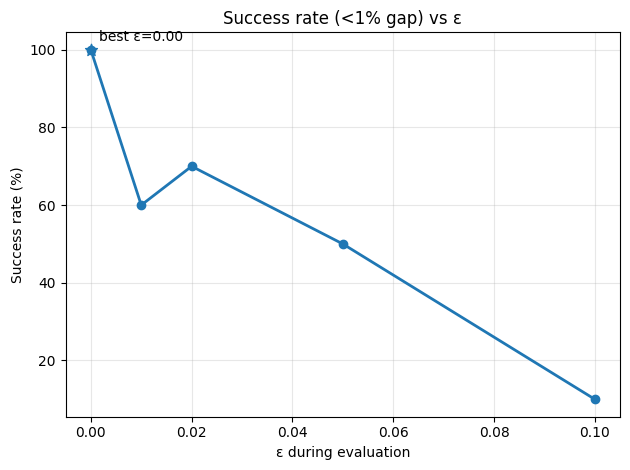

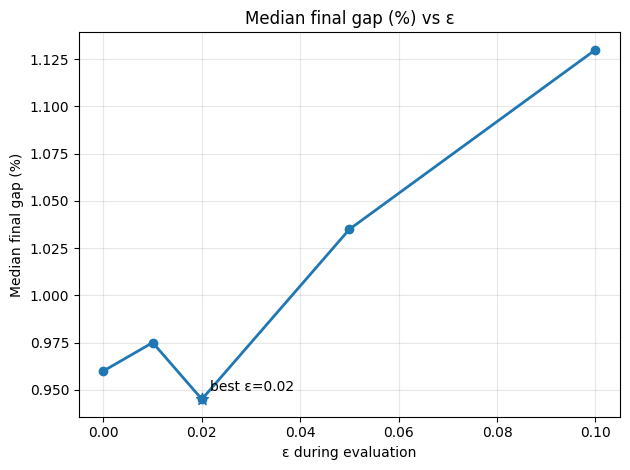

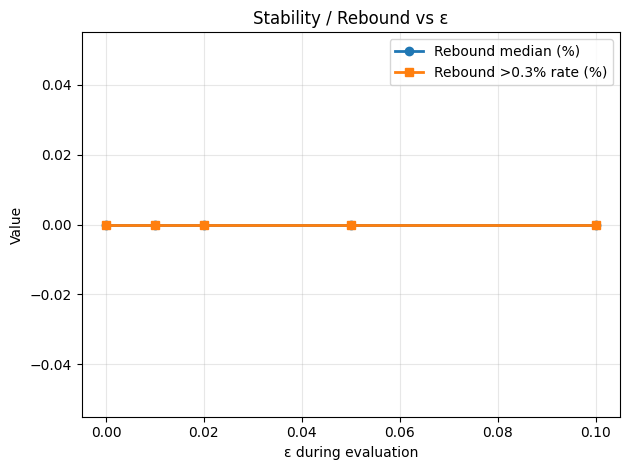

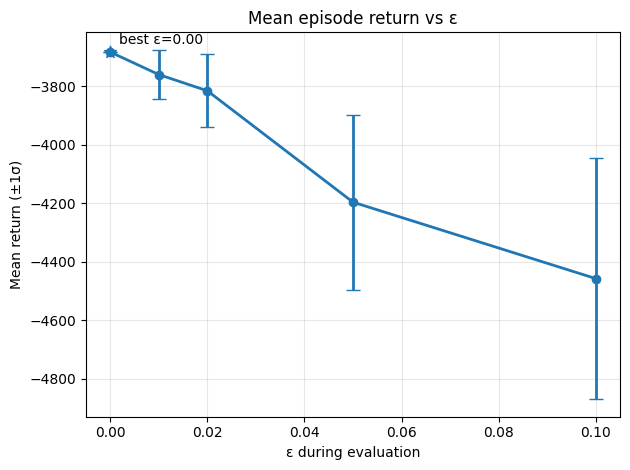

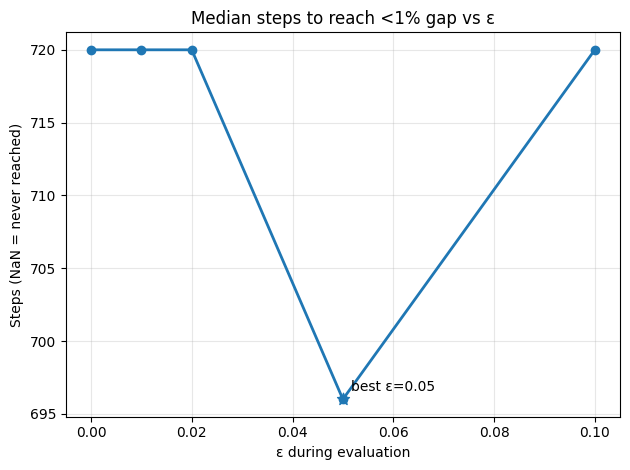

In [5]:
# =========================
# Visualize exploration evaluation
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Turn the list of dicts into a DataFrame and sort by eps
df = pd.DataFrame(eval_results).sort_values("eps").reset_index(drop=True)

# Print a compact table
with pd.option_context("display.float_format", "{:,.3f}".format):
    print("\n=== Exploration Strategy Summary ===")
    print(df[[
        "eps",
        "episodes",
        "mean_return",
        "std_return",
        "median_final_gap_%",
        "success_rate_% (<1% gap)",
        "median_steps_to_1%",
        "rebound_median_%",
        "rebound_>0.3%_rate_%"
    ]])

# Convenience arrays
x = df["eps"].to_numpy()
succ = df["success_rate_% (<1% gap)"].to_numpy()
gap  = df["median_final_gap_%"].to_numpy()
ret_mean = df["mean_return"].to_numpy()
ret_std  = df["std_return"].to_numpy()
rebound_med = df["rebound_median_%"].to_numpy()
rebound_rate = df["rebound_>0.3%_rate_%"].to_numpy()
steps1 = df["median_steps_to_1%"].to_numpy()

# Helper to mark the best point on each curve
def annotate_best(ax, xs, ys, better="max"):
    if better == "max":
        i = int(np.nanargmax(ys))
    else:
        i = int(np.nanargmin(ys))
    ax.scatter([xs[i]], [ys[i]], s=80, marker="*", zorder=5)
    ax.annotate(f"best ε={xs[i]:.2f}",
                (xs[i], ys[i]),
                textcoords="offset points",
                xytext=(6, 6))

# 1) Success rate (higher is better)
plt.figure()
plt.plot(x, succ, marker="o", linewidth=2)
annotate_best(plt.gca(), x, succ, better="max")
plt.title("Success rate (<1% gap) vs ε")
plt.xlabel("ε during evaluation"); plt.ylabel("Success rate (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2) Median final gap (lower is better)
plt.figure()
plt.plot(x, gap, marker="o", linewidth=2)
annotate_best(plt.gca(), x, gap, better="min")
plt.title("Median final gap (%) vs ε")
plt.xlabel("ε during evaluation"); plt.ylabel("Median final gap (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3) Rebound metrics (both lower is better)
plt.figure()
plt.plot(x, rebound_med, marker="o", linewidth=2, label="Rebound median (%)")
plt.plot(x, rebound_rate, marker="s", linewidth=2, label="Rebound >0.3% rate (%)")
plt.title("Stability / Rebound vs ε")
plt.xlabel("ε during evaluation"); plt.ylabel("Value")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4) Mean return with ±1 std error bars (higher is better)
plt.figure()
plt.errorbar(x, ret_mean, yerr=ret_std, fmt="-o", capsize=5, linewidth=2)
annotate_best(plt.gca(), x, ret_mean, better="max")
plt.title("Mean episode return vs ε")
plt.xlabel("ε during evaluation"); plt.ylabel("Mean return (±1σ)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5) Speed to target: median steps to first time <1% (lower is better)
plt.figure()
# Replace NaN (never reached) with top of axis for visibility
y = steps1.copy()
plt.plot(x, y, marker="o", linewidth=2)
annotate_best(plt.gca(), x, np.where(np.isnan(y), np.inf, y), better="min")
plt.title("Median steps to reach <1% gap vs ε")
plt.xlabel("ε during evaluation"); plt.ylabel("Steps (NaN = never reached)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Episode 1/180 | Return(sum): -13772.7 | Avg reward/step: -19.129 | End BF gap: 2.10 | Steps: 720 | eps=0.986
Episode 2/180 | Return(sum): -12827.4 | Avg reward/step: -17.816 | End BF gap: 2.61 | Steps: 720 | eps=0.973
Episode 3/180 | Return(sum): -12660.2 | Avg reward/step: -17.584 | End BF gap: 2.67 | Steps: 720 | eps=0.959
Episode 4/180 | Return(sum): -11255.0 | Avg reward/step: -15.632 | End BF gap: 2.71 | Steps: 720 | eps=0.945
Episode 5/180 | Return(sum): -11369.8 | Avg reward/step: -15.791 | End BF gap: 2.66 | Steps: 720 | eps=0.932
Episode 6/180 | Return(sum): -12047.0 | Avg reward/step: -16.732 | End BF gap: 3.32 | Steps: 720 | eps=0.918
Episode 7/180 | Return(sum): -12239.9 | Avg reward/step: -17.000 | End BF gap: 2.83 | Steps: 720 | eps=0.904
Episode 8/180 | Return(sum): -11694.0 | Avg reward/step: -16.242 | End BF gap: 3.00 | Steps: 720 | eps=0.891
Episode 9/180 | Return(sum): -9878.4 | Avg reward/step: -13.720 | End BF gap: 2.83 | Steps: 720 | eps=0.877
Episode 10/180 | Ret

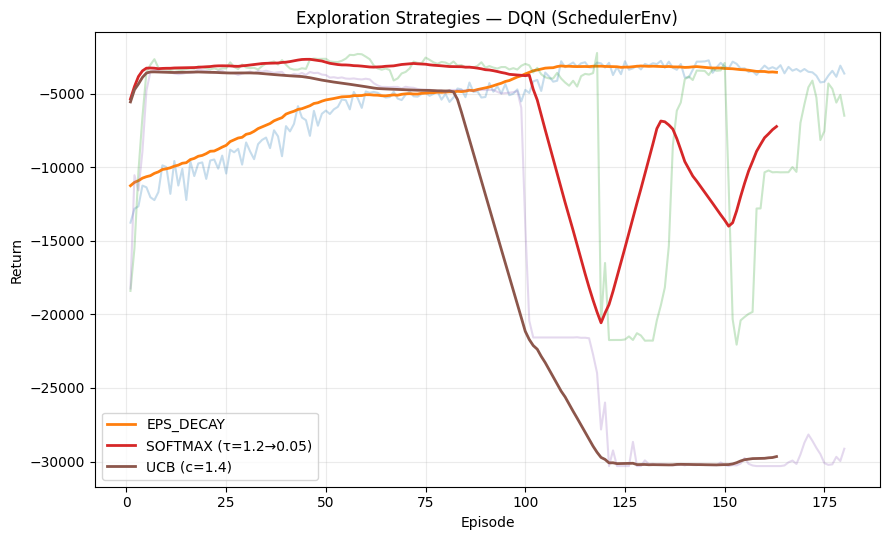

In [ ]:
# =========================
# EXTRA: Exploration strategy variants + comparison plot
# =========================
import math
import numpy as np
import matplotlib.pyplot as plt

# ---- helpers
def _masked_logits(q_np, mask):
    if mask is None:
        return q_np
    m = q_np.copy()
    bad = ~mask.astype(bool)
    m[bad] = -1e9
    return m

def _softmax_sample(q_np, mask, tau):
    logits = _masked_logits(q_np / max(1e-8, tau), mask if mask is not None else None)
    # numerically stable
    logits -= logits.max()
    p = np.exp(logits)
    p_sum = p.sum()
    if p_sum <= 0 or not np.isfinite(p_sum):
        return int(np.argmax(logits))
    p /= p_sum
    return int(np.random.choice(len(q_np), p=p))

# ---- Strategy 1: EPS_DECAY is your original DQNTrainer (no change)

# ---- Strategy 2: SOFTMAX (Boltzmann) trainer
class DQNTrainerSoftmax(DQNTrainer):
    def __init__(self, env, cfg, tau_start=1.2, tau_end=0.05, tau_decay_steps=50_000):
        super().__init__(env, cfg)
        self.tau_start = float(tau_start)
        self.tau_end = float(tau_end)
        self.tau = self.tau_start
        self.tau_decay = (self.tau_start - self.tau_end) / max(1, tau_decay_steps)

    def _select_action(self, s_vec: np.ndarray, mask: np.ndarray | None) -> int:
        with torch.no_grad():
            q = self.policy(torch.tensor(s_vec, dtype=torch.float32, device=self.device).unsqueeze(0))[0]
            q_np = q.detach().cpu().numpy()
        a = _softmax_sample(q_np, mask, self.tau)
        # temperature schedule
        if self.tau > self.tau_end:
            self.tau = max(self.tau_end, self.tau - self.tau_decay)
        return a

# ---- Strategy 3: UCB-style trainer (simple per-action counts)
class DQNTrainerUCB(DQNTrainer):
    def __init__(self, env, cfg, c=1.4):
        super().__init__(env, cfg)
        self.c = float(c)
        self.action_counts = np.ones(self.n_actions, dtype=np.int64)  # start at 1 to avoid div/0
        self.t = 1

    def _select_action(self, s_vec: np.ndarray, mask: np.ndarray | None) -> int:
        with torch.no_grad():
            q = self.policy(torch.tensor(s_vec, dtype=torch.float32, device=self.device).unsqueeze(0))[0]
            q_np = q.detach().cpu().numpy()
        # UCB bonus only for valid actions
        valid = np.arange(self.n_actions) if mask is None else np.where(mask)[0]
        scores = np.full(self.n_actions, -1e9, dtype=np.float32)
        for a in valid:
            bonus = self.c * math.sqrt(math.log(self.t + 1) / float(self.action_counts[a]))
            scores[a] = q_np[a] + bonus
        a = int(np.argmax(scores))
        # book-keeping
        self.action_counts[a] += 1
        self.t += 1
        return a

# ---- Run a small suite and plot
def run_exploration_suite(episodes=180, seed=7, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    # common config
    base_cfg = DQNConfig(
        episodes=episodes,
        steps_per_episode=24*30,
        batch_size=128,
        gamma=0.99,
        lr=3e-4,
        eps_start=1.0,
        eps_end=0.05,
        eps_decay_steps=50_000,
        target_sync=1000,
        replay_capacity=100_000,
        seed=seed,
        device=device
    )

    curves = {}

    # 1) EPS_DECAY (your baseline DQNTrainer)
    env1 = SchedulerEnv(verbose=False)
    trainer1 = DQNTrainer(env1, base_cfg)
    res1 = trainer1.train()
    curves["EPS_DECAY"] = np.asarray(res1["returns"], dtype=np.float32)

    # 2) SOFTMAX (Boltzmann)
    env2 = SchedulerEnv(verbose=False)
    trainer2 = DQNTrainerSoftmax(env2, base_cfg, tau_start=1.2, tau_end=0.05, tau_decay_steps=50_000)
    res2 = trainer2.train()
    curves["SOFTMAX (τ=1.2→0.05)"] = np.asarray(res2["returns"], dtype=np.float32)

    # 3) UCB-style (c=1.4)
    env3 = SchedulerEnv(verbose=False)
    trainer3 = DQNTrainerUCB(env3, base_cfg, c=1.4)
    res3 = trainer3.train()
    curves["UCB (c=1.4)"] = np.asarray(res3["returns"], dtype=np.float32)

    return curves

def _smooth(y, frac=0.10):
    if len(y) == 0: return y
    w = max(1, int(len(y) * frac))
    k = np.ones(w) / w
    return np.convolve(y, k, mode="valid")

def plot_exploration_curves(curves_dict):
    plt.figure(figsize=(9,5.5))
    for label, y in curves_dict.items():
        x = np.arange(1, len(y)+1)
        plt.plot(x, y, alpha=0.25)  # raw (faint)
        ys = _smooth(y, 0.10)
        xs = np.arange(1, len(ys)+1)
        plt.plot(xs, ys, linewidth=2, label=label)
    plt.title("Exploration Strategies — DQN (SchedulerEnv)")
    plt.xlabel("Episode"); plt.ylabel("Return")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

# ---- Run it (uncomment to execute)
curves = run_exploration_suite(episodes=180, seed=7)
plot_exploration_curves(curves)


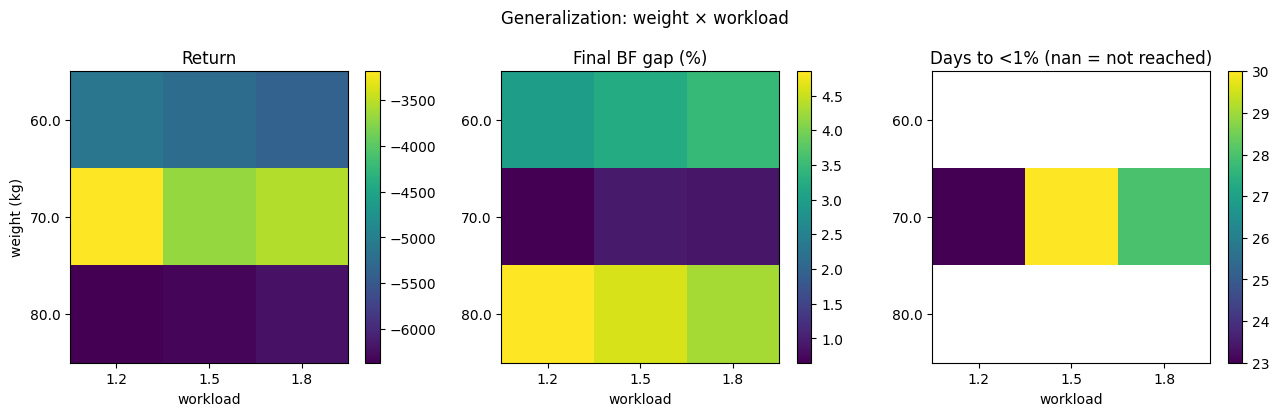

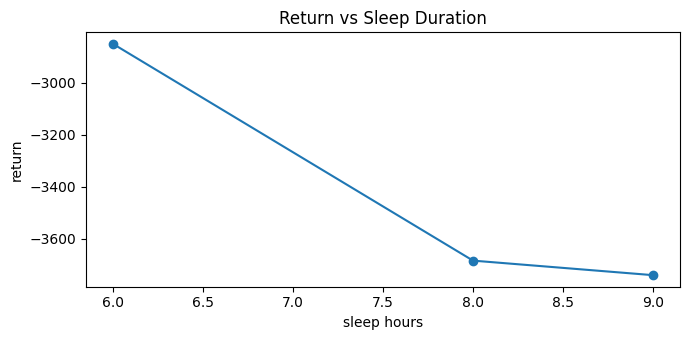

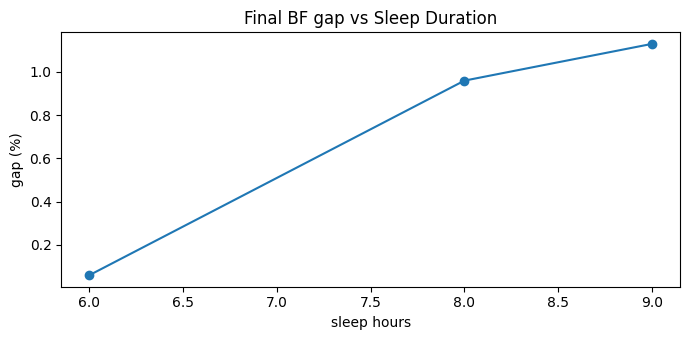

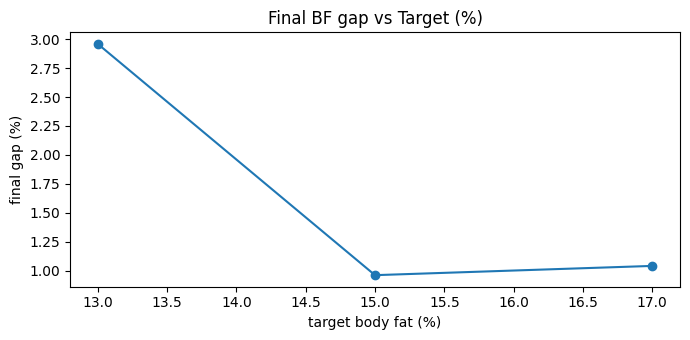


=== Generalization Summary ===
suite=weight×workload, weight=60.00, workload=1.20, return=-5118.46, final_gap=2.98, days_to_1pct=nan
suite=weight×workload, weight=60.00, workload=1.50, return=-5240.69, final_gap=3.23, days_to_1pct=nan
suite=weight×workload, weight=60.00, workload=1.80, return=-5361.24, final_gap=3.47, days_to_1pct=nan
suite=weight×workload, weight=70.00, workload=1.20, return=-3185.95, final_gap=0.65, days_to_1pct=23
suite=weight×workload, weight=70.00, workload=1.50, return=-3683.89, final_gap=0.96, days_to_1pct=30
suite=weight×workload, weight=70.00, workload=1.80, return=-3547.39, final_gap=0.91, days_to_1pct=28
suite=weight×workload, weight=80.00, workload=1.20, return=-6368.00, final_gap=4.85, days_to_1pct=nan
suite=weight×workload, weight=80.00, workload=1.50, return=-6307.69, final_gap=4.60, days_to_1pct=nan
suite=weight×workload, weight=80.00, workload=1.80, return=-6210.87, final_gap=4.29, days_to_1pct=nan
suite=sleep, sleep=6, return=-2849.95, final_gap=0.06

In [ ]:
# =========================
# Generalization evaluation (no code changes to training)
# =========================
import os, math, numpy as np
import matplotlib.pyplot as plt
import torch

# --- 0) Load a trained policy or grab the active trainer ---
def load_policy_if_needed(env):
    """
    Returns a callable act_greedy(obs, mask) that matches trainer.act_greedy.
    Prefers an in-memory 'trainer' if present; otherwise loads the checkpoint.
    """
    # Case A: you're still in the same session and have 'trainer'
    if "trainer" in globals() and hasattr(trainer, "act_greedy"):
        return trainer.act_greedy, trainer.cfg

    # Case B: load from disk (Set A used QNet)
    ckpt_path = "dqn_scheduler_best.pt"  # change if you saved to a different name
    if not os.path.exists(ckpt_path):
        raise FileNotFoundError(f"Checkpoint '{ckpt_path}' not found and no trainer in memory.")

    # Rebuild a QNet like in Set A
    obs_dim = len(DQNConfig().obs_key_order)
    n_actions = env.action_space.n
    policy_net = QNet(obs_dim, n_actions)
    data = torch.load(ckpt_path, map_location="cpu")
    policy_net.load_state_dict(data["policy_state_dict"])
    policy_net.eval()

    class Wrapper:
        def __init__(self, cfg):
            self.cfg = cfg
        def act_greedy(self, obs, mask):
            s = obs_to_vector(obs, DQNConfig().obs_key_order)
            with torch.no_grad():
                q = policy_net(torch.tensor(s, dtype=torch.float32).unsqueeze(0))[0].numpy()
            # mask-aware argmax
            if mask is None:
                return int(np.argmax(q))
            valid = np.where(mask)[0]
            if valid.size == 0:
                return int(np.argmax(q))
            masked = np.full_like(q, -1e9, dtype=np.float32)
            masked[valid] = q[valid]
            return int(np.argmax(masked))

    return Wrapper(DQNConfig()).act_greedy, DQNConfig()

# --- 1) One-episode greedy evaluation helper ---
def run_greedy_episode(env, act_fn, max_steps=None):
    obs, info = env.reset()
    mask = extract_mask(info, env)
    done = False
    ep_ret, steps = 0.0, 0
    max_steps = max_steps or 24 * env.days_per_episode

    while not done and steps < max_steps:
        a = act_fn(obs, mask)
        obs, r, term, trunc, info = env.step(a)
        ep_ret += float(r)
        steps += 1
        mask = extract_mask(info, env)
        done = bool(term) or bool(trunc)

    # Metrics
    final_gap = float(info.get("body_fat_gap", np.nan))
    bf_hist = np.asarray(env.state["body_fat_history"], dtype=float)
    tgt = env.target_body_fat
    days_to_within_1 = np.nan
    if bf_hist.size:
        within = np.where(np.abs(bf_hist - tgt) < 1.0)[0]
        if within.size:
            days_to_within_1 = int(within[0] + 1)

    return {
        "return": ep_ret,
        "final_gap": final_gap,
        "days_to_1pct": days_to_within_1,
        "steps": steps,
    }

# --- 2) Define your generalization suites (no env code changes) ---
weights   = [60.0, 70.0, 80.0]       # kg  (70 was the training default)
heights   = [165.0, 175.0, 185.0]    # cm
ages      = [20, 35, 50]             # years
workloads = [1.2, 1.5, 1.8]          # sedentary -> high
sleep_h   = [6, 8, 9]                # hours
targets   = [13.0, 15.0, 17.0]       # % body fat target

# You can toggle which axes to sweep for plotting below
axis_weight_work = True
axis_sleep_only  = True
axis_target_only = True

# --- 3) Run: weight × workload grid (example heatmaps) ---
base_kwargs = dict(gender=1, age=25, height=175.0, weight=70.0,
                   target_body_fat=15.0, days_per_episode=30,
                   workloads=1.5, sleep_duration=8, verbose=False)

act_fn, _cfg = load_policy_if_needed(SchedulerEnv(**base_kwargs))

results = []

# A) Weight × Workload
if axis_weight_work:
    R = np.zeros((len(weights), len(workloads)), dtype=float)
    G = np.zeros_like(R)
    D = np.full_like(R, np.nan)
    for i, w in enumerate(weights):
        for j, wl in enumerate(workloads):
            env = SchedulerEnv(**{**base_kwargs, "weight": w, "workloads": wl})
            out = run_greedy_episode(env, act_fn)
            R[i, j] = out["return"]
            G[i, j] = out["final_gap"]
            D[i, j] = out["days_to_1pct"]
            results.append({"suite":"weight×workload", "weight":w, "workload":wl, **out})

    # Heatmaps
    fig, ax = plt.subplots(1, 3, figsize=(13, 4.2))
    im0 = ax[0].imshow(R, aspect="auto")
    ax[0].set_title("Return"); ax[0].set_xticks(range(len(workloads))); ax[0].set_yticks(range(len(weights)))
    ax[0].set_xticklabels(workloads); ax[0].set_yticklabels(weights); ax[0].set_xlabel("workload"); ax[0].set_ylabel("weight (kg)")
    plt.colorbar(im0, ax=ax[0])
    im1 = ax[1].imshow(G, aspect="auto")
    ax[1].set_title("Final BF gap (%)"); ax[1].set_xticks(range(len(workloads))); ax[1].set_yticks(range(len(weights)))
    ax[1].set_xticklabels(workloads); ax[1].set_yticklabels(weights); ax[1].set_xlabel("workload")
    plt.colorbar(im1, ax=ax[1])
    im2 = ax[2].imshow(D, aspect="auto")
    ax[2].set_title("Days to <1% (nan = not reached)"); ax[2].set_xticks(range(len(workloads))); ax[2].set_yticks(range(len(weights)))
    ax[2].set_xticklabels(workloads); ax[2].set_yticklabels(weights); ax[2].set_xlabel("workload")
    plt.colorbar(im2, ax=ax[2])
    plt.suptitle("Generalization: weight × workload"); plt.tight_layout(); plt.show()

# B) Sleep-only curve
if axis_sleep_only:
    ret_s, gap_s, day_s = [], [], []
    for sh in sleep_h:
        env = SchedulerEnv(**{**base_kwargs, "sleep_duration": sh})
        out = run_greedy_episode(env, act_fn)
        ret_s.append(out["return"]); gap_s.append(out["final_gap"]); day_s.append(out["days_to_1pct"])
        results.append({"suite":"sleep", "sleep":sh, **out})

    x = np.arange(len(sleep_h))
    plt.figure(figsize=(7,3.5))
    plt.plot(sleep_h, ret_s, marker="o")
    plt.title("Return vs Sleep Duration"); plt.xlabel("sleep hours"); plt.ylabel("return"); plt.tight_layout(); plt.show()

    plt.figure(figsize=(7,3.5))
    plt.plot(sleep_h, gap_s, marker="o")
    plt.title("Final BF gap vs Sleep Duration"); plt.xlabel("sleep hours"); plt.ylabel("gap (%)"); plt.tight_layout(); plt.show()

# C) Target-only curve
if axis_target_only:
    ret_t, gap_t, day_t = [], [], []
    for tgt in targets:
        env = SchedulerEnv(**{**base_kwargs, "target_body_fat": tgt})
        out = run_greedy_episode(env, act_fn)
        ret_t.append(out["return"]); gap_t.append(out["final_gap"]); day_t.append(out["days_to_1pct"])
        results.append({"suite":"target", "target":tgt, **out})

    plt.figure(figsize=(7,3.5))
    plt.plot(targets, gap_t, marker="o")
    plt.title("Final BF gap vs Target (%)"); plt.xlabel("target body fat (%)"); plt.ylabel("final gap (%)"); plt.tight_layout(); plt.show()

# --- 4) Print a compact table of all cases ---
def _fmt(x):
    if isinstance(x, float) and (math.isnan(x) or math.isinf(x)):
        return "nan"
    return f"{x:.2f}" if isinstance(x, float) else str(x)

print("\n=== Generalization Summary ===")
for row in results:
    keys = ["suite","weight","workload","sleep","target","return","final_gap","days_to_1pct"]
    msg = []
    for k in keys:
        if k in row:
            v = row[k]
            msg.append(f"{k}={_fmt(v)}")
    print(", ".join(msg))


Baseline M | Return:  -3683.9 | Final BF gap: 0.96% | Days to <1%: 30
  Female L | Return:  -5253.2 | Final BF gap: 4.54% | Days to <1%: nan
    Male H | Return:  -6837.5 | Final BF gap: 3.79% | Days to <1%: nan


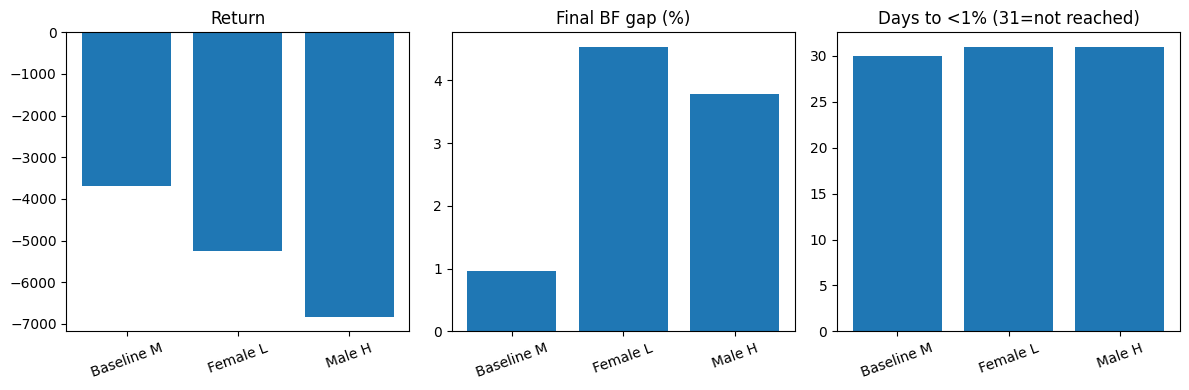

In [ ]:
# ---------- Post-training generalization over 3 people (no code changes to training) ----------
import numpy as np
import matplotlib.pyplot as plt

# Helper: run one greedy rollout with the trained policy
def eval_profile(trainer, profile_kwargs, steps_per_episode=None):
    env = SchedulerEnv(**profile_kwargs, verbose=False)
    cfg_steps = steps_per_episode or trainer.cfg.steps_per_episode

    obs, info = env.reset()
    mask = extract_mask(info, env)
    done = False
    total_return = 0.0
    steps = 0
    day_under_1 = np.nan

    while (not done) and (steps < cfg_steps):
        a = trainer.act_greedy(obs, mask)
        obs, r, term, trunc, info = env.step(a)
        total_return += r
        steps += 1
        done = bool(term) or bool(trunc)
        mask = extract_mask(info, env)

        # when a day ends, env logs body_fat_history; detect first day < 1%
        if len(env.state["body_fat_history"]) > 0 and np.isnan(day_under_1):
            gap_today = abs(env.state["body_fat_history"][-1] - env.target_body_fat)
            if gap_today < 1.0:
                day_under_1 = env.state["day_of_episode"]  # day index after increment

    final_gap = float(info.get("body_fat_gap", np.nan))
    return {
        "return": float(total_return),
        "final_gap": final_gap,
        "days_to_lt1": day_under_1
    }

# Three diverse “people” (adjust as you like)
# gender: 1=male, 0=female (matches your env’s body-fat formula)
profiles = {
    "Baseline M": dict(gender=1, age=25, height=175.0, weight=70.0, target_body_fat=15.0,
                       workloads=1.5, sleep_duration=8),
    "Female L":   dict(gender=0, age=30, height=165.0, weight=60.0, target_body_fat=22.0,
                       workloads=1.5, sleep_duration=8),
    "Male H":     dict(gender=1, age=40, height=180.0, weight=85.0, target_body_fat=18.0,
                       workloads=1.3, sleep_duration=7),
}

# Run evaluation
results = {name: eval_profile(trainer, cfg) for name, cfg in profiles.items()}
for name, r in results.items():
    print(f"{name:>10} | Return: {r['return']:8.1f} | Final BF gap: {r['final_gap']:4.2f}% | "
          f"Days to <1%: {r['days_to_lt1']}")

# Quick visualization
names = list(results.keys())
rets  = [results[n]["return"] for n in names]
gaps  = [results[n]["final_gap"] for n in names]
days  = [results[n]["days_to_lt1"] if not np.isnan(results[n]["days_to_lt1"]) else None for n in names]

fig, axs = plt.subplots(1,3, figsize=(12,4))
axs[0].bar(names, rets);  axs[0].set_title("Return");        axs[0].tick_params(axis='x', rotation=20)
axs[1].bar(names, gaps);  axs[1].set_title("Final BF gap (%)"); axs[1].tick_params(axis='x', rotation=20)
axs[2].bar(names, [d if d is not None else 31 for d in days])
axs[2].set_title("Days to <1% (31=not reached)"); axs[2].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()


In [7]:
# ---------- Hour-by-hour logging for a full episode (safe mask handling) ----------
import numpy as np

ACTION_LABEL = {
    0: "skip",
    1: "meal: light",
    2: "meal: balanced",
    3: "meal: heavy",
    4: "snack: high-carb",
    5: "snack: high-protein",
    6: "supplements",
    7: "exercise: light",
    8: "exercise: moderate",
    9: "exercise: heavy",
}
SCHEDULE_LABEL = {"sleep": "sleep", "work": "work", "walk": "walk", "action": "(choose action)"}

def _get_mask_from(info, env):
    m = extract_mask(info, env)
    if m is None:
        m = env.get_action_mask()
    return np.asarray(m, dtype=bool)

def rollout_and_log(env, trainer, days_to_show=None, greedy=True):
    if days_to_show is None:
        days_to_show = env.days_per_episode
    days_to_show = int(min(days_to_show, env.days_per_episode))

    records = []
    obs, info = env.reset()
    mask = _get_mask_from(info, env)
    done, step = False, 0

    print(f"\n=== Day 0 .. Day {days_to_show-1} ===")
    while not done:
        hour = int(env.state["current_hours"])
        day  = int(env.state["day_of_episode"])
        if day >= days_to_show:
            break

        schedule = env.scheduler[hour]

        print(f"Hour {hour}, Day {day}")
        print(f"  Daily Calories Intake: {env.state['daily_calories_intake']:.2f}")
        print(f"  Daily Calories Burned: {env.state['daily_calories_burned']:.2f}")

        if schedule in ("sleep", "work", "walk"):
            a = 0
            label = SCHEDULE_LABEL.get(schedule, schedule)
        else:
            if greedy:
                a = trainer.act_greedy(obs, mask)
            else:
                valid = np.where(mask)[0]
                a = int(np.random.choice(valid)) if valid.size else 0
            label = ACTION_LABEL.get(int(a), f"action {int(a)}")

        obs, r, term, trunc, info = env.step(a)
        step += 1
        mask = _get_mask_from(info, env)
        done = bool(term) or bool(trunc)

        bf = float(env.state["current_body_fat"])
        print(f"  Reward: {float(r):.2f}")
        print(f"  Body Fat: {bf:.2f}")
        print(f"{hour:02d}:00 \u2192 {label}")

        records.append((day, hour, label, float(r)))

    return records


In [8]:
all_records = rollout_and_log(env, trainer, days_to_show=30, greedy=True)



=== Day 0 .. Day 29 ===
Hour 0, Day 0
  Daily Calories Intake: 0.00
  Daily Calories Burned: 0.00
  Reward: -29.57
  Body Fat: 16.98
00:00 → sleep
Hour 1, Day 0
  Daily Calories Intake: 0.00
  Daily Calories Burned: 7.35
  Reward: -29.58
  Body Fat: 16.98
01:00 → sleep
Hour 2, Day 0
  Daily Calories Intake: 0.00
  Daily Calories Burned: 14.70
  Reward: -28.58
  Body Fat: 16.98
02:00 → sleep
Hour 3, Day 0
  Daily Calories Intake: 0.00
  Daily Calories Burned: 22.05
  Reward: -28.58
  Body Fat: 16.98
03:00 → sleep
Hour 4, Day 0
  Daily Calories Intake: 0.00
  Daily Calories Burned: 29.40
  Reward: -28.59
  Body Fat: 16.98
04:00 → sleep
Hour 5, Day 0
  Daily Calories Intake: 0.00
  Daily Calories Burned: 36.75
  Reward: -28.59
  Body Fat: 16.98
05:00 → sleep
Hour 6, Day 0
  Daily Calories Intake: 0.00
  Daily Calories Burned: 44.10
  Reward: -10.96
  Body Fat: 16.98
06:00 → meal: heavy
Hour 7, Day 0
  Daily Calories Intake: 1000.00
  Daily Calories Burned: 44.10
  Reward: 1.40
  Body Fat

In [9]:
# ---------- Gantt-style schedule plot ----------
import matplotlib.pyplot as plt

COLOR_MAP = {
    "sleep": "blue",
    "work": "gray",
    "walk": "cyan",
    "skip": "lightgray",
    "meal: light": "orange",
    "meal: balanced": "gold",
    "meal: heavy": "red",
    "snack: high-carb": "pink",
    "snack: high-protein": "purple",
    "supplement": "brown",     # tolerate both spellings
    "supplements": "brown",
    "exercise: light": "lightgreen",
    "exercise: moderate": "lime",
    "exercise: heavy": "darkgreen",
}

def plot_gantt(all_records, days_to_show, hours_per_day=24, title="Agent Schedule (Gantt Chart)"):
    # one horizontal lane per day
    row_h, row_gap = 1.2, 0.5
    fig_h = max(2.5, 1.5 * days_to_show)
    fig, ax = plt.subplots(figsize=(24, fig_h))

    for (day, hour, label, reward) in all_records:
        y = day * (row_h + row_gap)
        ax.broken_barh([(hour, 1)], (y, row_h),
                       facecolors=COLOR_MAP.get(label, "lightgray"),
                       edgecolors="black")
        ax.text(hour + 0.5, y + row_h/2, label,
                ha="center", va="center", fontsize=8, rotation=90, color="black")

    ax.set_xlim(0, hours_per_day)
    ax.set_ylim(-0.2, days_to_show * (row_h + row_gap))
    ax.set_xticks(range(0, hours_per_day + 1, 2))
    ax.set_yticks([i*(row_h+row_gap)+row_h/2 for i in range(days_to_show)])
    ax.set_yticklabels([f"Day {i}" for i in range(days_to_show)])
    ax.set_xlabel("Hour of Day"); ax.set_ylabel("Day"); ax.set_title(title, fontsize=16)

    handles = [plt.Rectangle((0,0),1,1, color=c) for c in COLOR_MAP.values()]
    ax.legend(handles, COLOR_MAP.keys(), bbox_to_anchor=(1.01, 1),
              loc="upper left", fontsize=9, title="Activities", ncol=1, frameon=False)

    plt.tight_layout()
    plt.show()


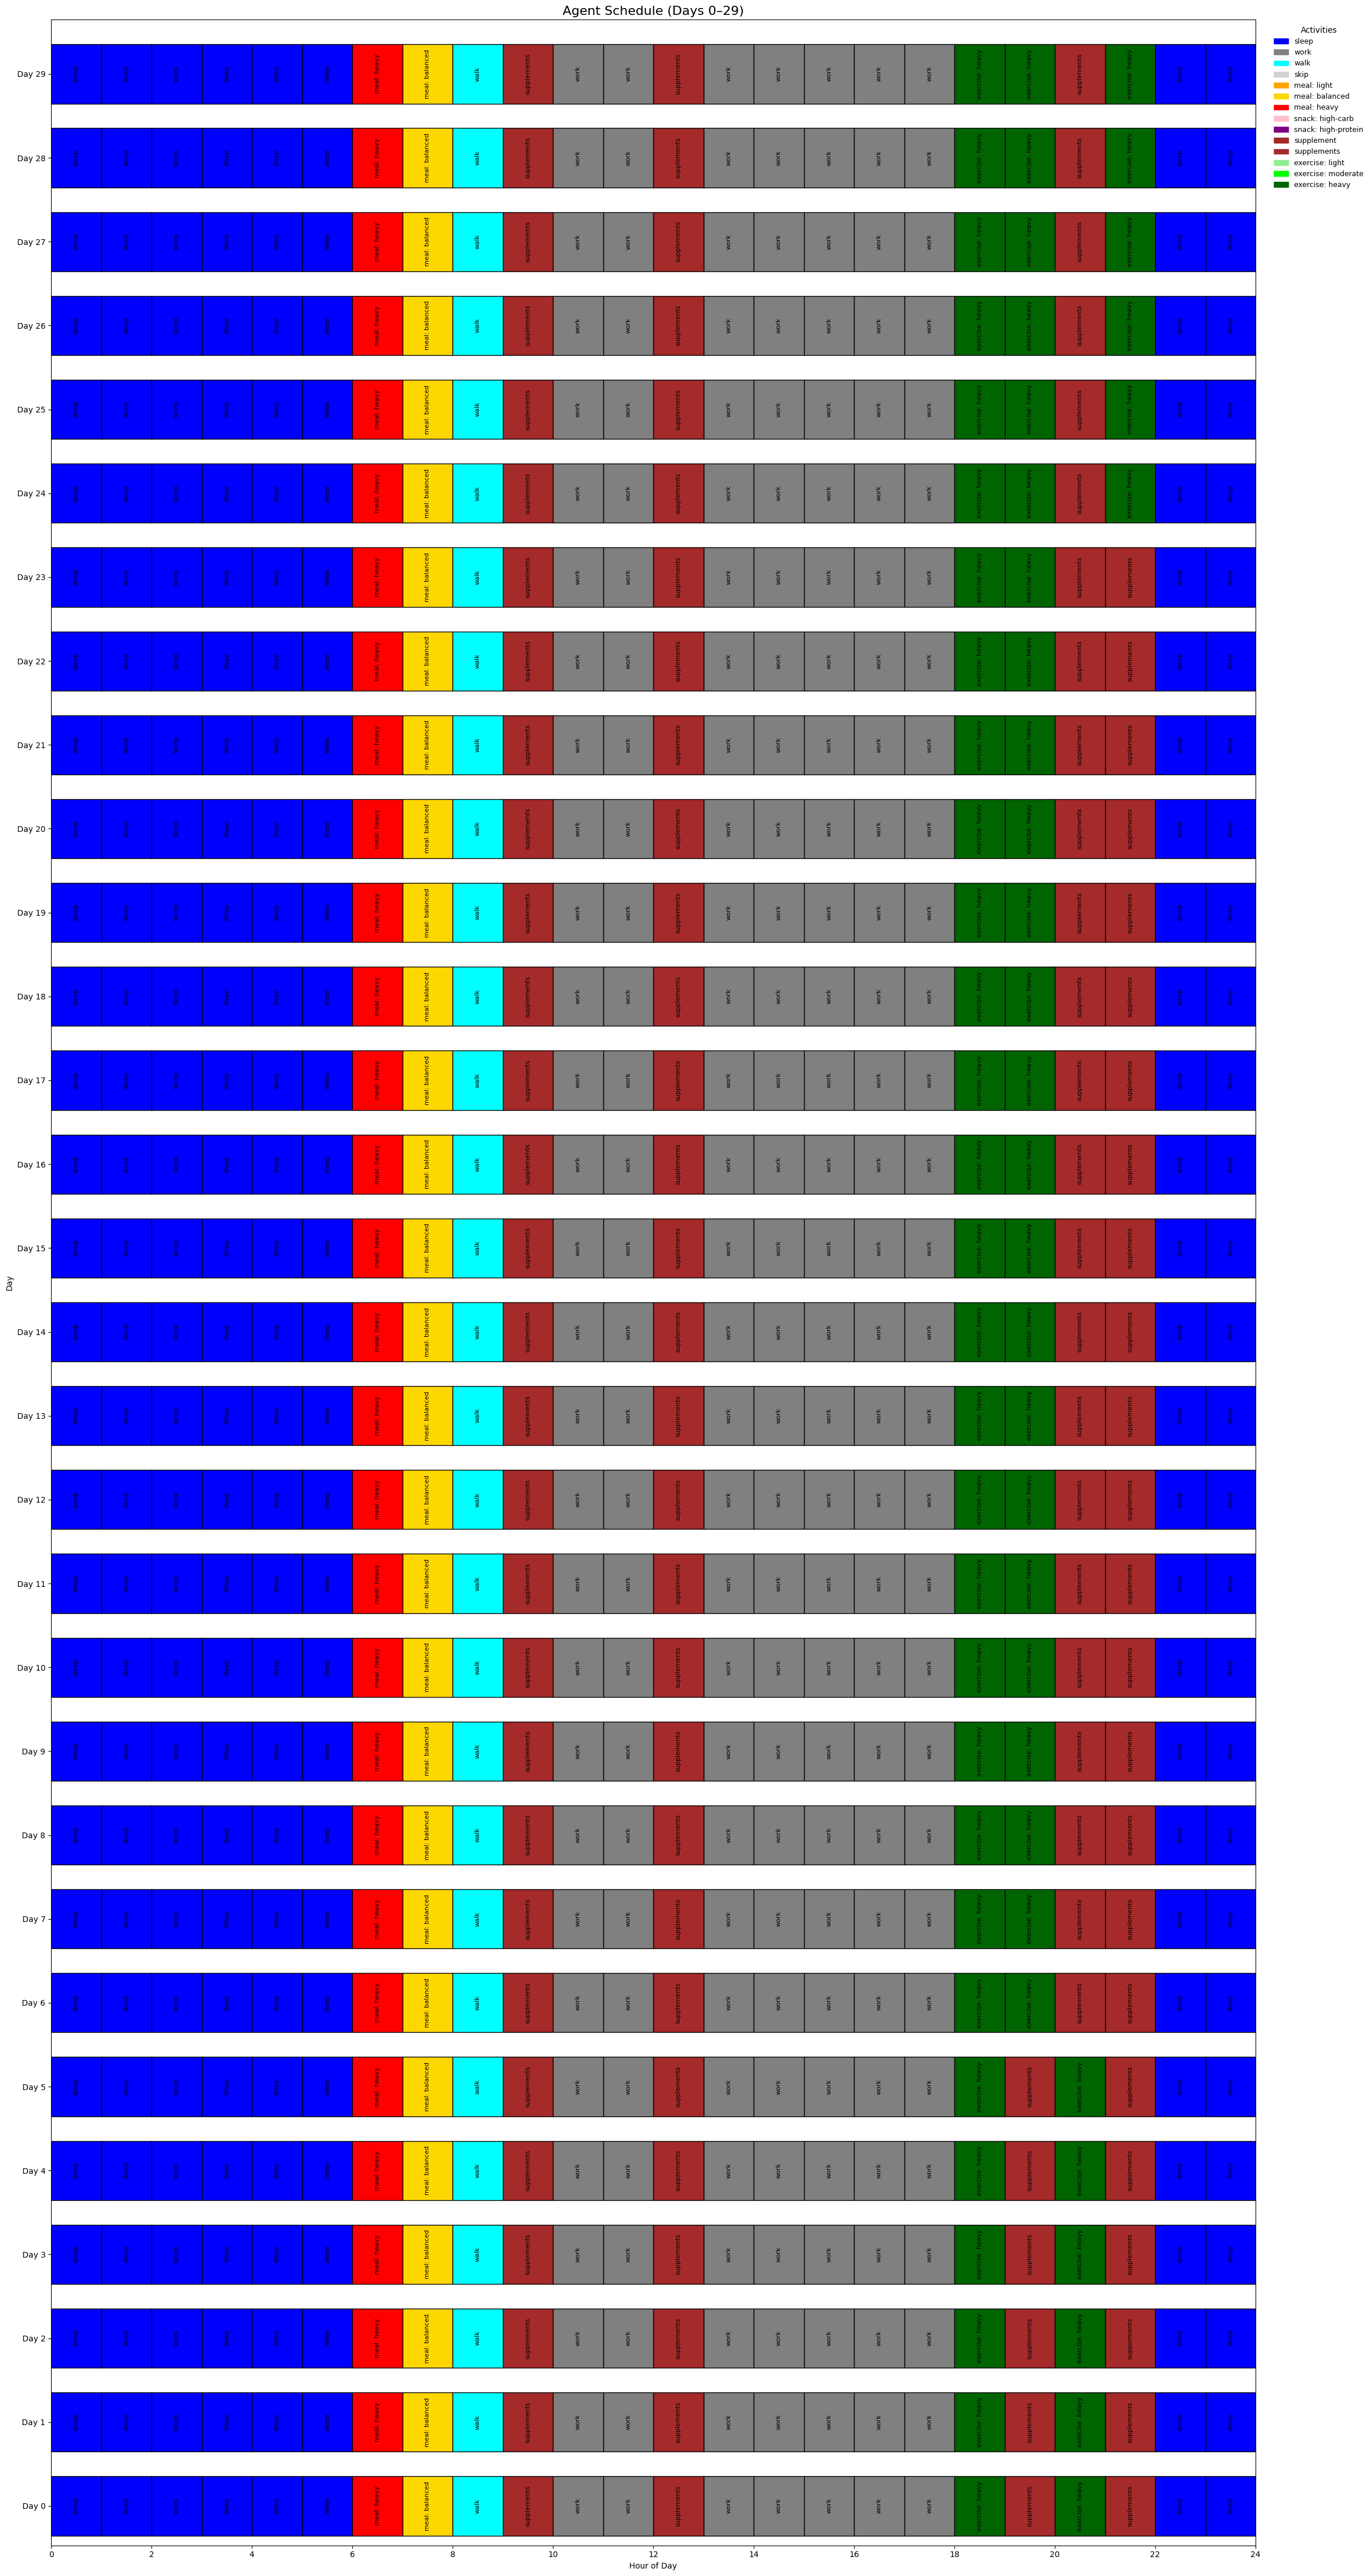

In [10]:
plot_gantt(all_records, days_to_show=30, hours_per_day=24,
           title="Agent Schedule (Days 0–29)")
